In [1]:
import pandas as pd
import re

df = pd.read_csv(r"D:\social_survey_job\raw_data\lagou.csv", encoding="gbk",header=None)

print("=== 前5行数据 ===")
print(df.head())
print("\n=== 所有字段名称 ===")
print(df.columns.tolist())
print(f"\n数据集大小：{df.shape[0]}行 , {df.shape[1]}列")
print("\n=== 缺失值统计 ===")
print(df.isnull().sum())

=== 前5行数据 ===
                  0                1           2           3      4  \
0          销售数据分析专员  家乐福广州 Gaungzhou      广州-天河区      5-8千/月  07-08   
1     游戏数据分析师（全球市场）             字节跳动          深圳    1.5-3万/月  07-08   
2         数据分析师（游戏）             哔哩哔哩      上海-杨浦区  1.5-2.5万/月  07-08   
3  36665-公共出行-数据分析师   深圳市腾讯计算机系统有限公司          深圳         NaN  07-08   
4            数据分析专家              饿了么  武汉-武汉经济...  1.8-2.5万/月  07-08   

                                                   5         6  \
0                                                 []        []   
1  ['深圳\xa0\xa0', '\xa0\xa03-4年经验\xa0\xa0', '\xa0...  ['民营公司']   
2  ['上海-杨浦区\xa0\xa0', '\xa0\xa03-4年经验\xa0\xa0', '...  ['上市公司']   
3  ['深圳\xa0\xa0', '\xa0\xa03-4年经验\xa0\xa0', '\xa0...  ['民营公司']   
4  ['武汉-武汉经济开发区\xa0\xa0', '\xa0\xa05-7年经验\xa0\xa0...  ['民营公司']   

                7                   8  \
0              []                  []   
1    ['10000人以上']  ['互联网/电子商务,计算机软件']   
2  ['1000-5000人']        ['互联网/电子商务']  

In [2]:
import pandas as pd
import re

df = pd.read_csv(r"D:\social_survey_job\raw_data\lagou.csv", encoding="gbk",header=None)

df.columns = ["job_name","company","city_en","city_area","salary","publish_date","col6","col7","col8","col9"]

keywords = ["大数据","数据分析","数据挖掘","人工智能","算法","数据开发","数据","工程师","AI","数据技术"]
df_filter = df[df["job_name"].str.contains('|'.join(keywords),case=False,na=False)].copy()

def parse_salary(s):
    if pd.isna(s):
        return None
    res = re.findall(r'(\d+\.?\d*)-(\d+\.?\d*)',str(s))
    if res:
        low = float(res[0][0])
        high = float(res[0][1])
        return (low+high)/2
    return None

df_filter["avg_salary"] = df_filter["salary"].apply(parse_salary)

df_clean = df_filter.dropna(subset=["avg_salary"])

print(f"筛选后岗位数量：{len(df_filter)}")
print(f"清洗完有效薪资样本：{len(df_clean)}")
print(df_clean[["job_name","city_area","salary","avg_salary"]].head(10))

筛选后岗位数量：4814
清洗完有效薪资样本：4814
                       job_name   city_area salary  avg_salary
0                      销售数据分析专员      5-8千/月  07-08         7.5
1                 游戏数据分析师（全球市场）    1.5-3万/月  07-08         7.5
2                     数据分析师（游戏）  1.5-2.5万/月  07-08         7.5
3              36665-公共出行-数据分析师         NaN  07-08         7.5
4                        数据分析专家  1.8-2.5万/月  07-08         7.5
5                         数据分析师    1-1.5万/月  07-08         7.5
6  商业智能部-数据分析专家/高级数据（C2M事业部）-杭州         NaN  07-08         7.5
7                         数据分析师    1.5-2万/月  07-08         7.5
8             主数据分析及工具开发 351203  1.2-2.4万/月  07-08         7.5
9                        数据分析专员      6-8千/月  07-08         7.5


In [8]:
#缺失值统计
missing=pd.DataFrame({
    '缺失数量':df_clean.isnull().sum(),
    '缺失占比(%)':round(df_clean.isnull().sum()/len(df_clean)*100,2)
})
print(missing)

              缺失数量  缺失占比(%)
job_name         0     0.00
company          0     0.00
city_en          0     0.00
city_area      115     2.39
salary           0     0.00
publish_date     0     0.00
col6             0     0.00
col7             0     0.00
col8             0     0.00
col9             0     0.00
avg_salary       0     0.00


      count  mean
city             
哈尔滨       6  8.75
嘉兴       14  8.04
福州       33  7.68
厦门       40  7.64
廊坊        5  7.60
佛山       63  7.59
重庆       77  7.58
宁波       77  7.57
深圳      526  7.53
武汉      191  7.52
日照        1  7.50
绍兴        1  7.50
曲靖        1  7.50
芜湖        8  7.50
新乡        1  7.50


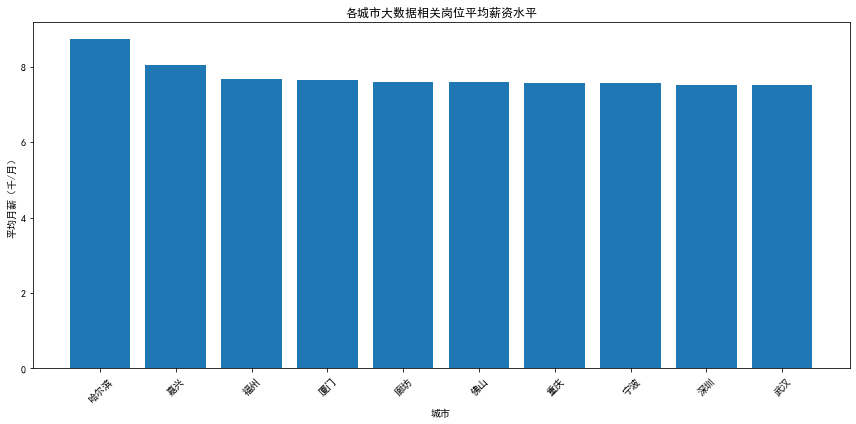

In [33]:
import matplotlib.pyplot as plt

df_clean["city"] = df_clean["city_en"].str.split("-").str[0]

city_salary = df_clean.groupby("city")["avg_salary"].agg(["count","mean"]).round(2)
city_salary = city_salary.sort_values("mean",ascending=False)
print(city_salary.head(15))

plt.rcParams["font.sans-serif"]=["SimHei"]
plt.rcParams["axes.unicode_minus"]=False

top10 = city_salary.head(10)
plt.figure(figsize=(12,6))
plt.bar(top10.index,top10["mean"])
plt.title("各城市大数据相关岗位平均薪资水平")
plt.xlabel("城市")
plt.ylabel("平均月薪（千/月）")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
!pip install jieba wordcloud

  Created wheel for jieba: filename=jieba-0.42.1-py3-none-any.whl size=19314477 sha256=d23629f2b654d653bdab9be5a801886ba6932078fdb6ff1206000a7e5c02ed93
  Stored in directory: c:\users\86182\appdata\local\pip\cache\wheels\ca\38\d8\dfdfe73bec1d12026b30cb7ce8da650f3f0ea2cf155ea018ae
Successfully built jieba


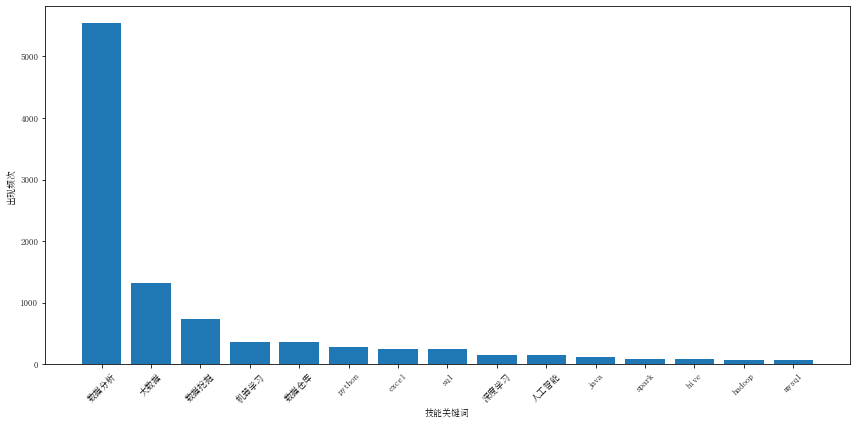

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams["font.sans-serif"]=["SimHei"]
plt.rcParams["axes.unicode_minus"]=False
df = pd.read_csv(r"D:\social_survey_job\raw_data\lagou.csv", encoding="gbk",header=None)

skill_words = {"python","java","sql","mysql","hadoop","hive","hbase","spark","flink",
               "机器学习","深度学习","大模型","人工智能","数据分析","数据挖掘","数据仓库",
               "大数据","excel","tableau","powerbi","kafka","redis"}

text1 = "".join(df_clean["col6"].dropna().tolist())
text2 = "".join(df_clean["col7"].dropna().tolist())
text3 = "".join(df_clean["col8"].dropna().tolist())
text4 = "".join(df_clean["col9"].dropna().tolist())
text_all = text1+text2+text3+text4

skill_list=[]
for s in skill_words:
    count=text_all.count(s)
    for _ in range(count):
        skill_list.append(s)

skill_count = Counter(skill_list)
top15_skill = skill_count.most_common(15)

skill_name = [i[0] for i in top15_skill]
skill_num = [i[1] for i in top15_skill]

plt.figure(figsize=(12,6))
plt.bar(skill_name,skill_num)
plt.title("")
plt.xlabel("技能关键词",fontproperties="SimSun",fontsize=9)
plt.ylabel("出现频次",fontproperties="SimSun",fontsize=9)
plt.xticks(rotation=45,fontproperties="SimSun",fontsize=9)
plt.yticks(fontproperties="SimSun",fontsize=9)
plt.tight_layout()
plt.savefig("高频技能柱状图.png",dpi=300,bbox_inches="tight")
plt.show()

In [9]:
df_clean.to_csv(r"D:\social_survey_job\raw_data\clean_data.csv",index=False,encoding="utf-8-sig")

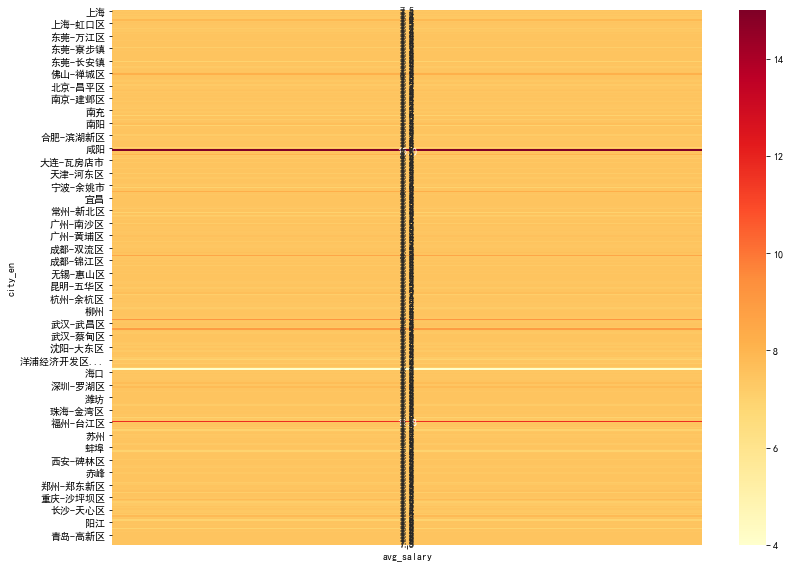

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

city_salary=df_clean.groupby("city_en")["avg_salary"].mean().reset_index()
pivot=city_salary.pivot_table(index='city_en',values='avg_salary')

plt.figure(figsize=(12,8))
ax=sns.heatmap(pivot,annot=True,cmap="YlOrRd",fmt=".1f")
ax.set_yticklabels(ax.get_yticklabels(),rotation=0)
plt.tight_layout()
plt.savefig("city_salary_heatmap.png",dpi=300)
plt.show()